In [1]:

from Scene import *
import matplotlib.pyplot as plt
import numpy as np

from scipy.special import hankel1, hankel2
from hankel import HankelTransform
from numpy import pi,pow,real,imag, abs
from numpy.linalg import norm, matrix_rank, matrix_power
from matplotlib.ticker import MultipleLocator

# ============================================================
# SETUP
# ============================================================
kb = 1
mu = 2 * np.pi / kb  # λ = 2π
stepsize = mu / 20  # h = λ/20

# Source position
rho_s = np.array([0.5 * mu, 10 * mu])

# Domain D: from (0,0) to (λ,λ)
domain_rho = np.array([0.0, 0.0])
domain_width = mu
domain_height = mu

# Receiver array: from (-λ, 1.5λ) to (2λ, 1.5λ), length 3λ
rec_start = np.array([-mu, 1.5 * mu])
rec_end = np.array([2 * mu, 1.5 * mu])

# Grid
x_range = [-2*mu, 3 * mu]  # -λ to 3λ
y_range = [-mu, 12 * mu]  # -λ to 12λ

def setup_scene_basic():
    """Create baseline scene WITHOUT receivers (for initial questions)."""
    scene = Scene(kb=kb, x_range=x_range, y_range=y_range, stepsize=stepsize)
    scene.add_source('Source', rho=rho_s, intensity=1.0, kb=kb)
    scene.add_domain('Object Domain', rho=domain_rho, width=domain_width, height=domain_height)
    return scene

def setup_scene(M=5):
    """Create baseline scene WITH receivers."""
    scene = Scene(kb=kb, x_range=x_range, y_range=y_range, stepsize=stepsize)
    scene.add_source('Source', rho=rho_s, intensity=1.0, kb=kb)
    scene.add_domain('Object Domain', rho=domain_rho, width=domain_width, height=domain_height)
    scene.add_contrast('Object', rho_0=[0.5 * mu, 0.5 * mu],
                   size=0.25 * mu, intensity=0.5, shape='circle')
    scene.add_receiver_array('Receivers',
                             geometry='line',
                             rho_start=rec_start,
                             rho_end=rec_end,
                             M=M)
    return scene


<span style="font-family:Ariel; font-size:24px; color:white">
1) Testing out the hankel matrix
</span>

In [2]:
# Order of the function
v = 0
# Argument (can be real or complex)
z = np.linspace(0.1, 5, 5)

# Compute Hankel functions h_i, where: i = kind; v = order; z = argument; order=ordering --> must be one of { 'C', 'F', 'A', or 'K' }
h1 = hankel1(1, z)
h2 = hankel2(1, z)

print("Hankel1:", h1)
print("Hankel2:", h2)

Hankel1: [ 0.04993753-6.45895109j  0.52736699-0.53090599j  0.48433959+0.16752612j
  0.02299807+0.41510944j -0.32757914+0.14786314j]
Hankel2: [ 0.04993753+6.45895109j  0.52736699+0.53090599j  0.48433959-0.16752612j
  0.02299807-0.41510944j -0.32757914-0.14786314j]


In [3]:
# Define transform parameters
ht = HankelTransform(nu=0, N=50, h=0.1)

# Function to transform
f = lambda r: np.exp(-r**2)

# Perform transform at k=1.0
result = ht.transform(f, 1.0)
print("Hankel Transform:", result)

Hankel Transform: (0.32857791616549015, array(0.))


<span style="font-family:Ariel; font-size:24px; color:white">
2) Formalizing the equations (1), (2), and (3)
</span>

In [4]:
print("Questions 1-2: Theory (see report)")

Questions 1-2: Theory (see report)


<span style="font-family:Ariel; font-size:24px; color:white">
3, 4, 5) Plotting the setup in a 2D coordinate system (kb = 1)
</span>


Questions 3-4: Configuration sketch


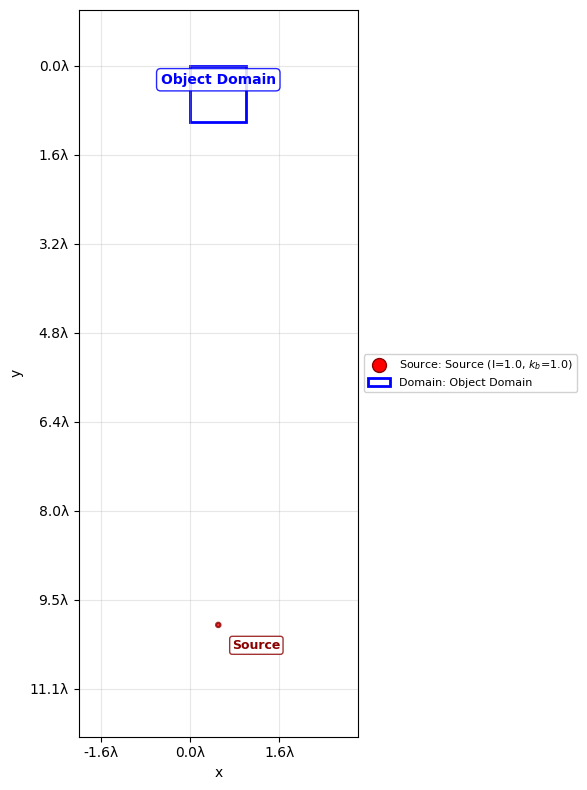

(<Figure size 1400x800 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

In [5]:
print("\nQuestions 3-4: Configuration sketch")
scene = setup_scene_basic()
scene.plot_scene()

<span style="font-family:Ariel; font-size:24px; color:white">
6) Indicent field on the 2D grid (kb = 1)
</span>

In [ ]:
print("\nQuestion 5: Grid points N")

N = int((domain_width / stepsize) * (domain_height / stepsize))
print(f"  N = {N} grid points ({int(domain_width / stepsize)}×{int(domain_height / stepsize)})")



Question 6: Incident field


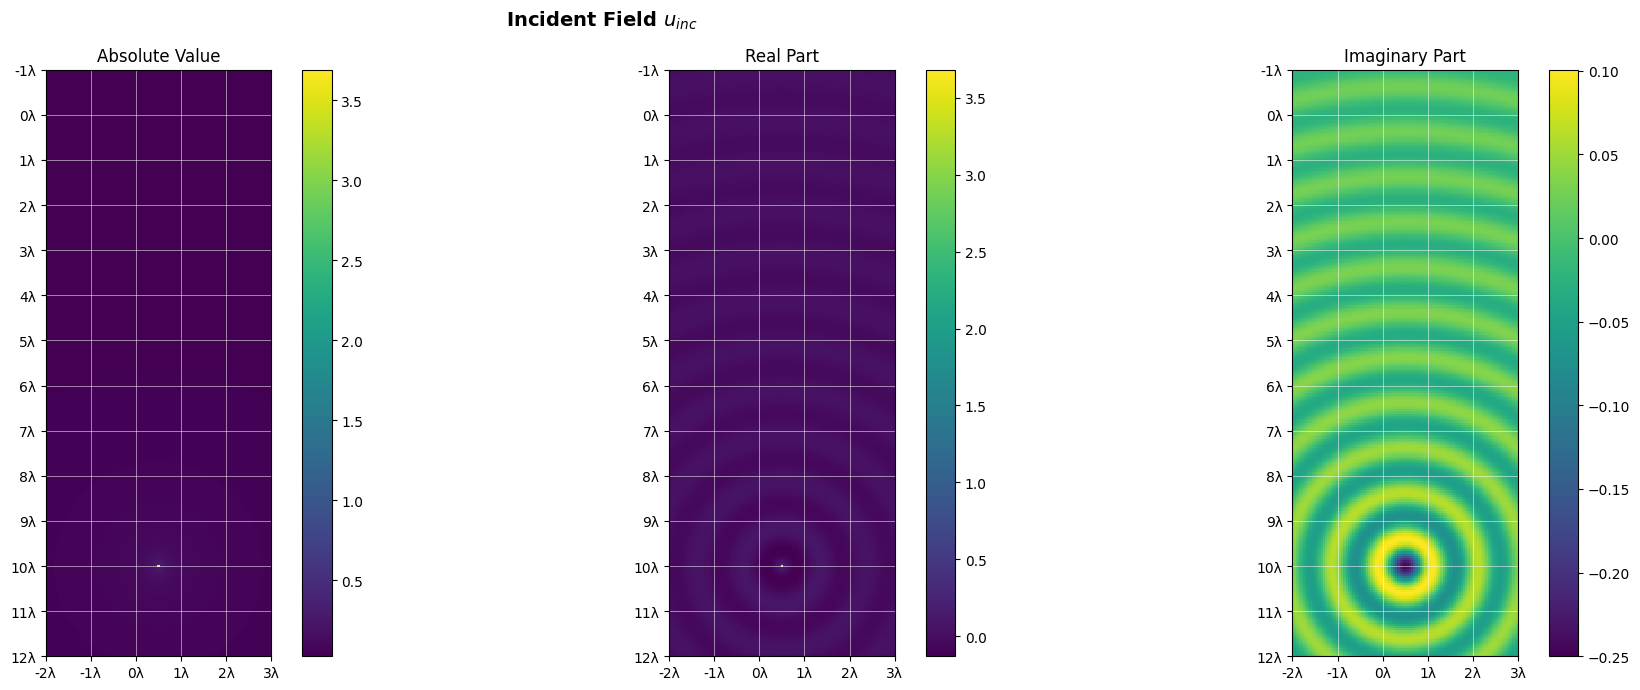

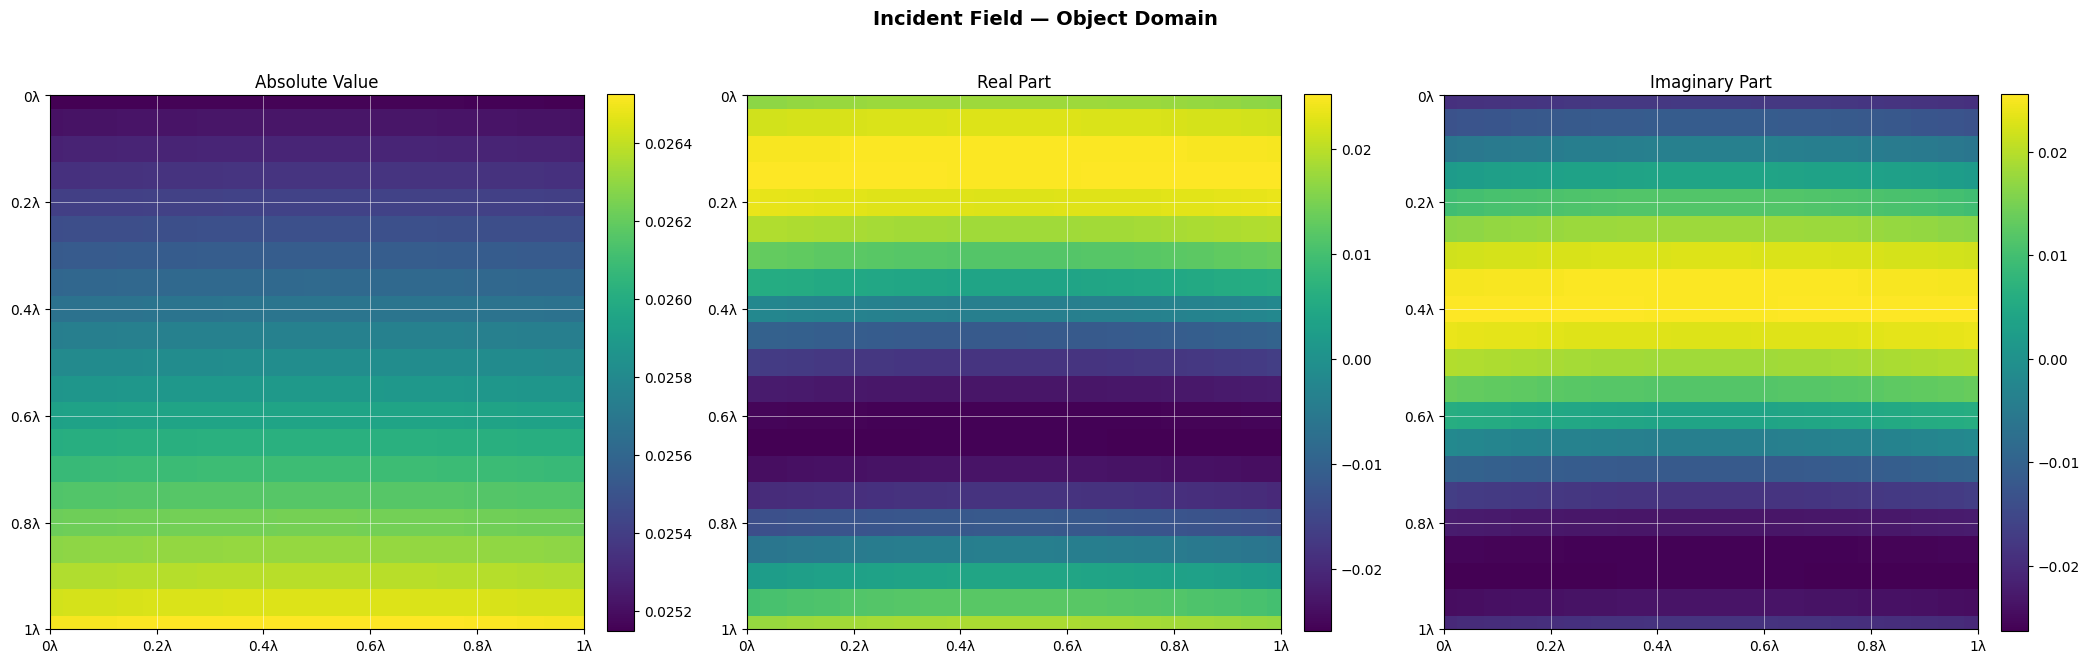

In [8]:
print("\nQuestion 6: Incident field")
scene.compute(field_type='incident')
scene.plot_field(field_type='incident')
scene.plot_domain_field('Object Domain', field_type='incident')

<span style="font-family:Ariel; font-size:24px; color:white">
7) Indicent field on the 2D grid for a different source location (kb = 2)
<br>
</span>
- Higher values of the parameter kb correspond to smaller wavelengths and should thus give a background field that varies more over time, which we can also see from the plots.

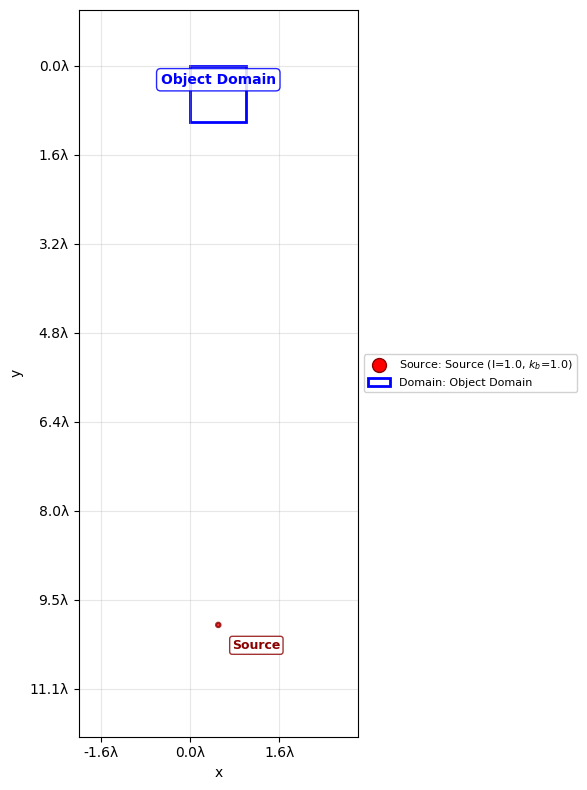

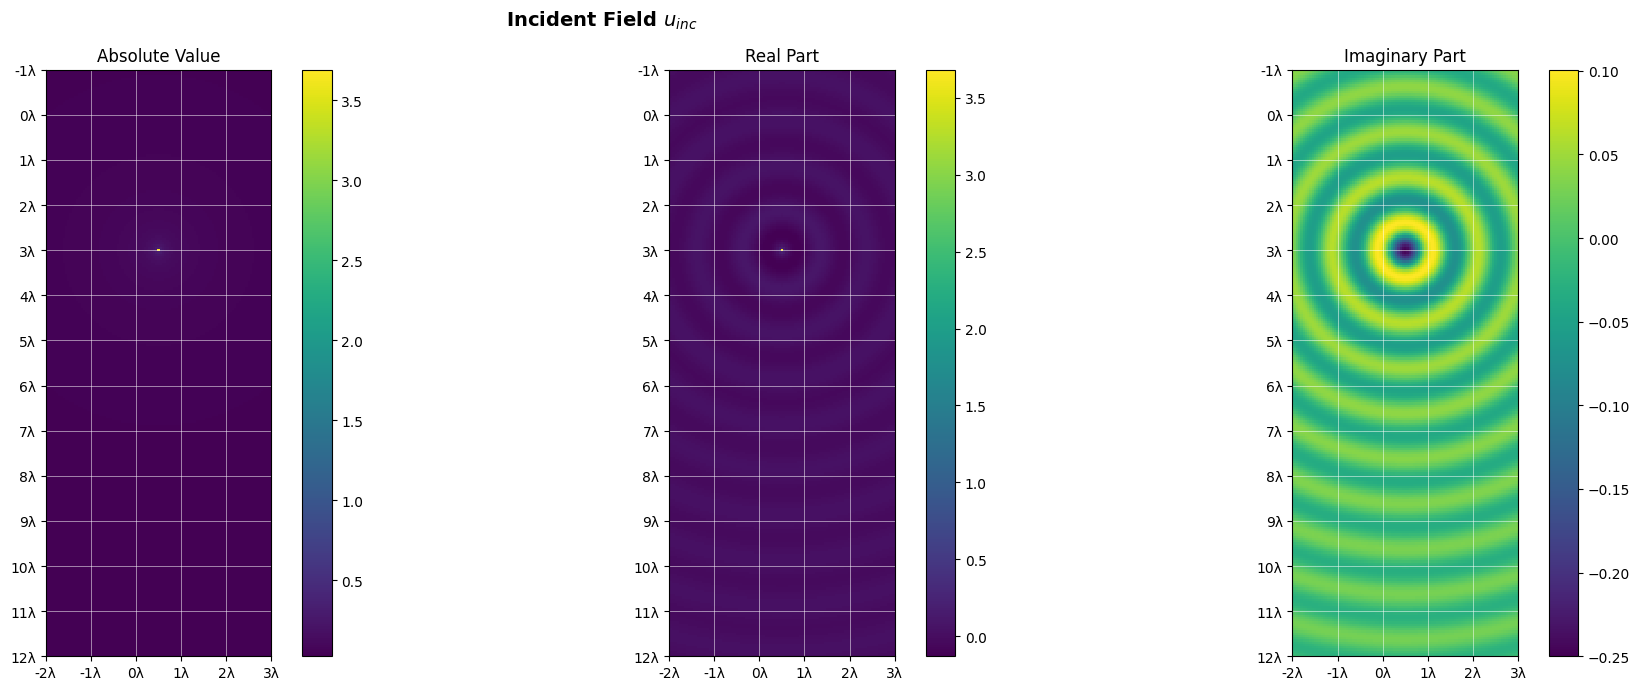

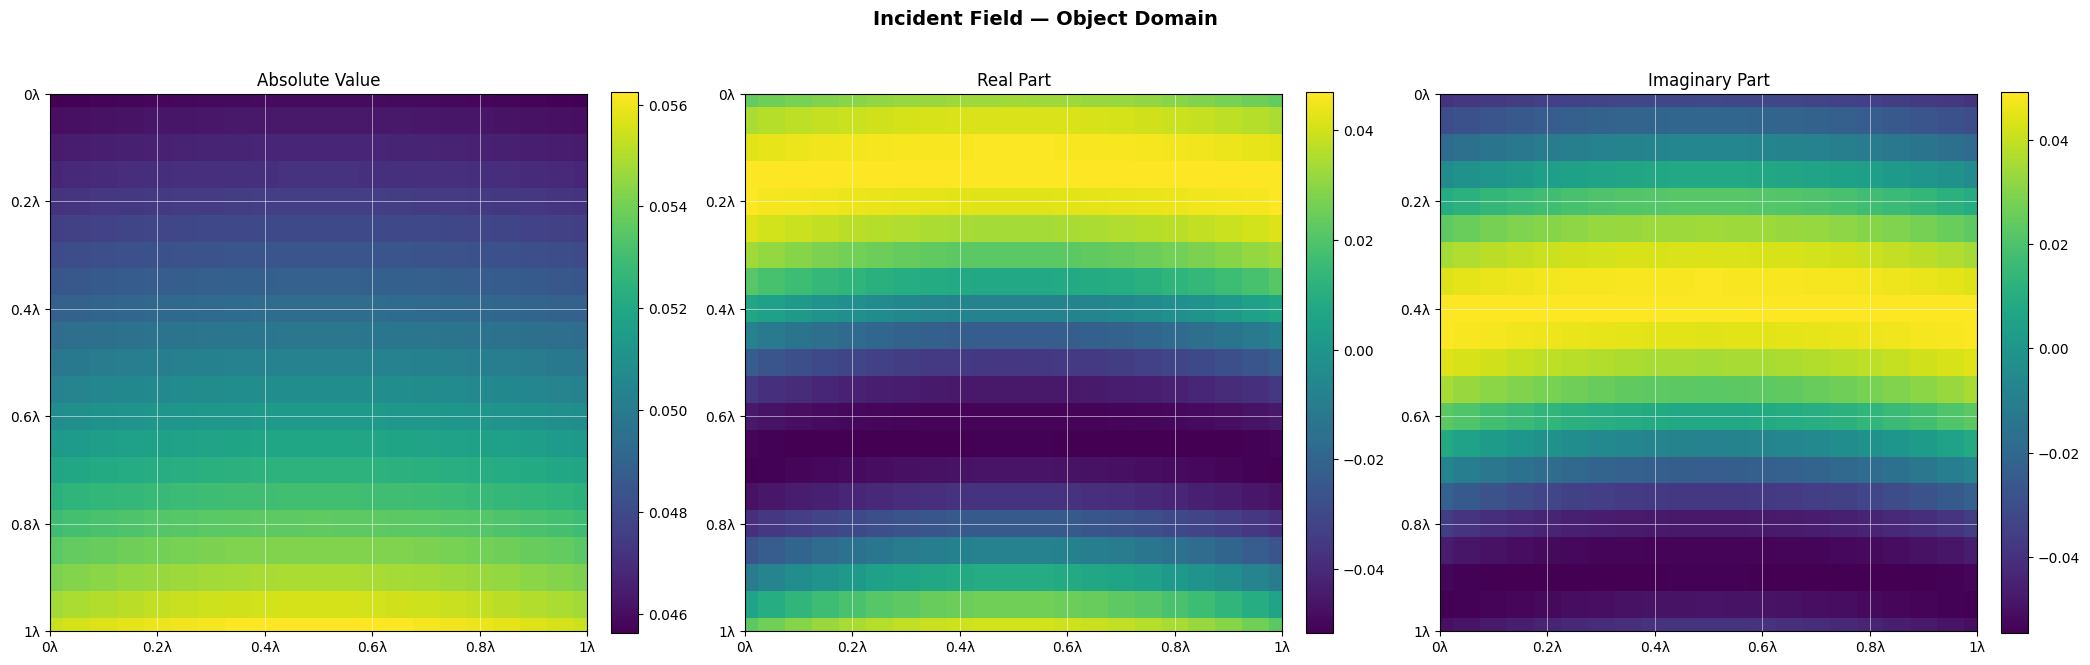

In [9]:
# 7a: Move source closer
scene_close = Scene(kb=kb, x_range=x_range, y_range=y_range, stepsize=stepsize)
scene_close.add_source('Source', rho=np.array([0.5 * mu, 3 * mu]), intensity=1.0, kb=kb)
scene_close.add_domain('Object Domain', rho=domain_rho, width=domain_width, height=domain_height)

scene.plot_scene()
scene_close.compute(field_type='incident')
scene_close.plot_field(field_type='incident')
scene_close.plot_domain_field('Object Domain', field_type='incident')

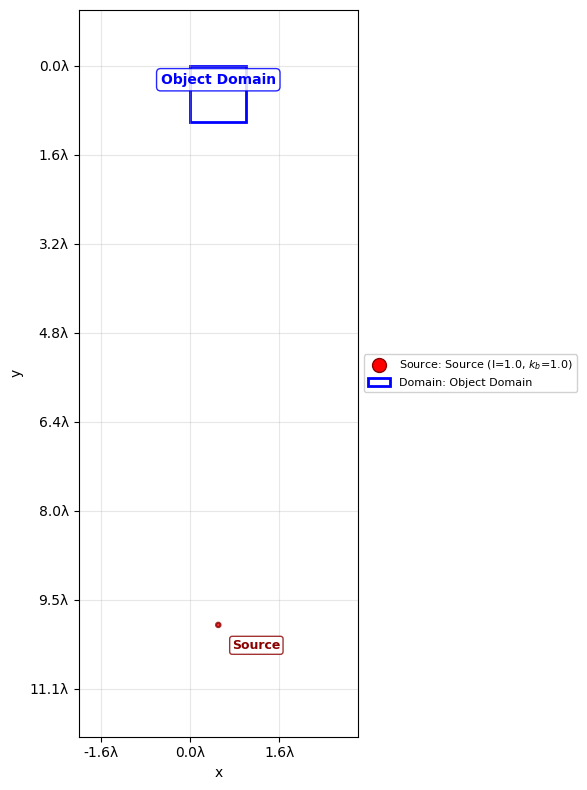

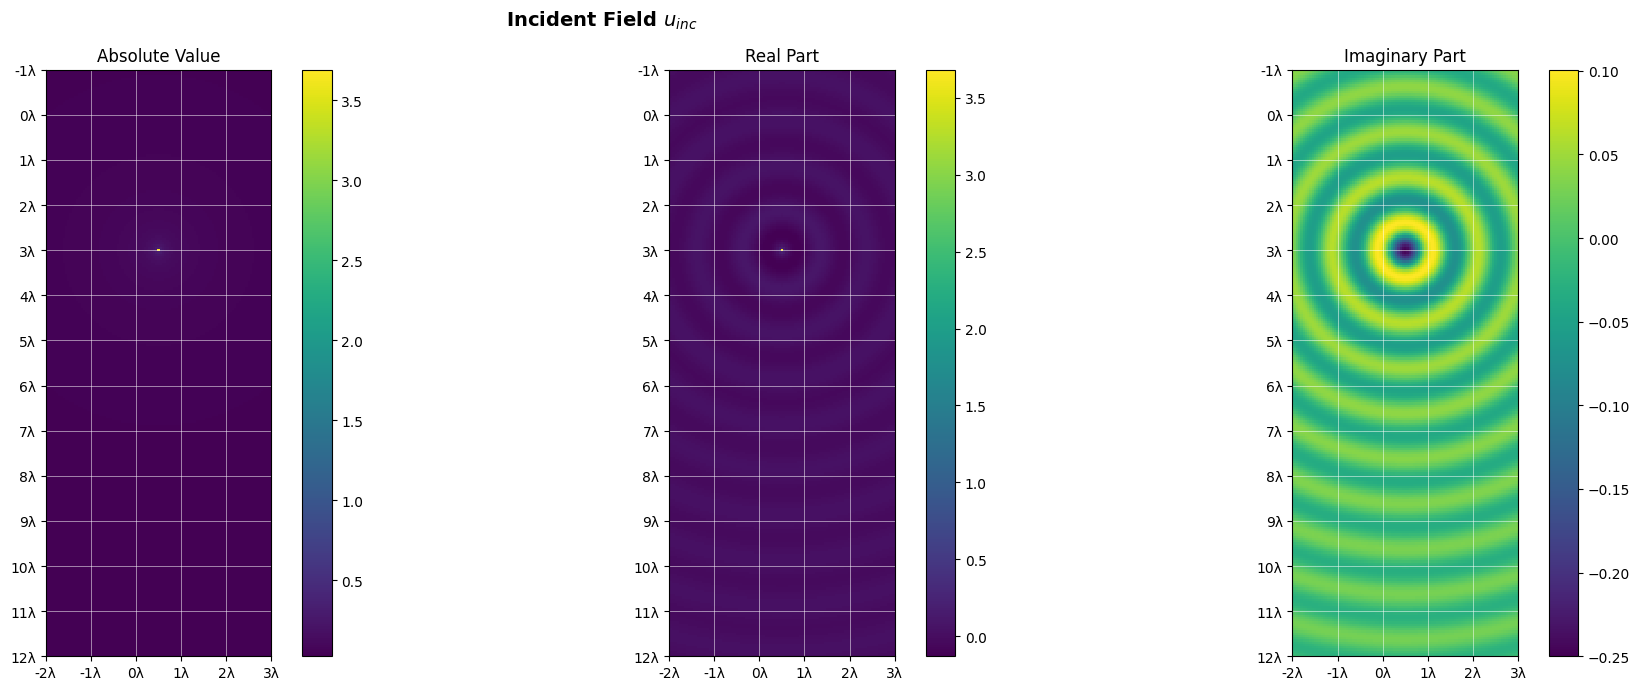

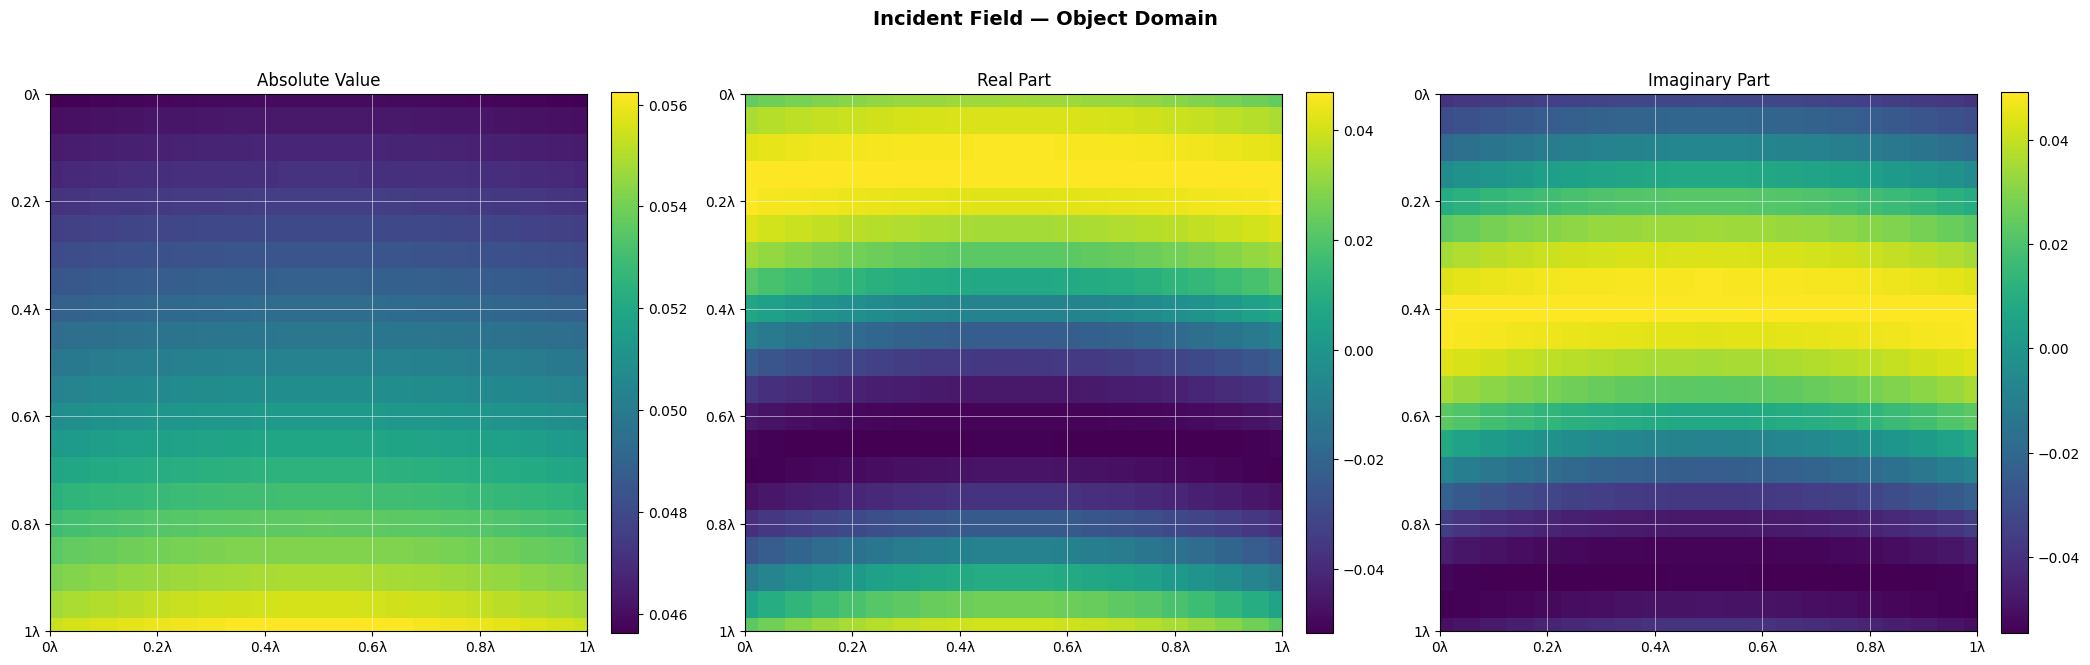

In [10]:
# 7b: Change wavenumber to kb=2
kb2 = 2
mu2 = 2 * np.pi / kb2
stepsize2 = mu2 / 20
scene_close = Scene(kb=kb, x_range=x_range, y_range=y_range, stepsize=stepsize)
scene_close.add_source('Source', rho=np.array([0.5 * mu, 3 * mu]), intensity=1.0, kb=kb)
scene_close.add_domain('Object Domain', rho=domain_rho, width=domain_width, height=domain_height)

scene.plot_scene()
scene_close.compute(field_type='incident')
scene_close.plot_field(field_type='incident')
scene_close.plot_domain_field('Object Domain', field_type='incident')

<span style="font-family:Ariel; font-size:24px; color:white">
8, 9) The effect of the contrast function on the wave propagation 
</span>


Questions 8-9: Contrast function


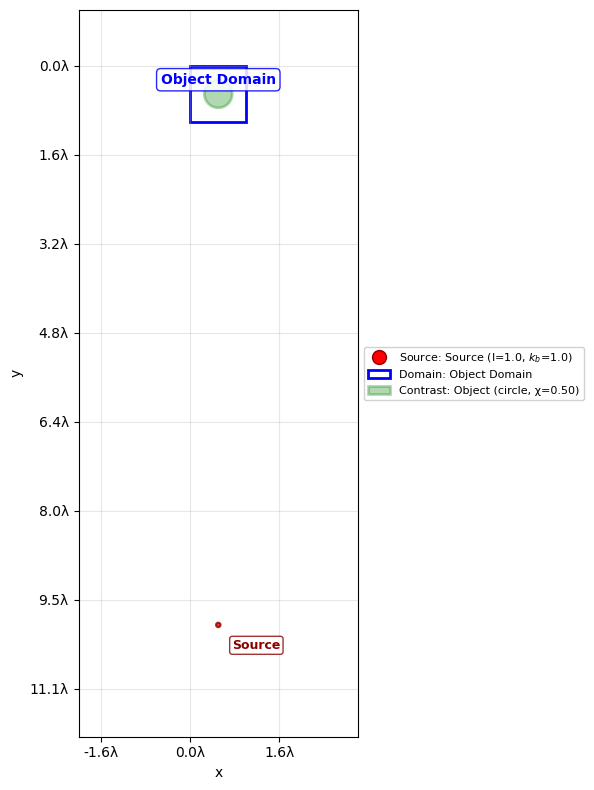

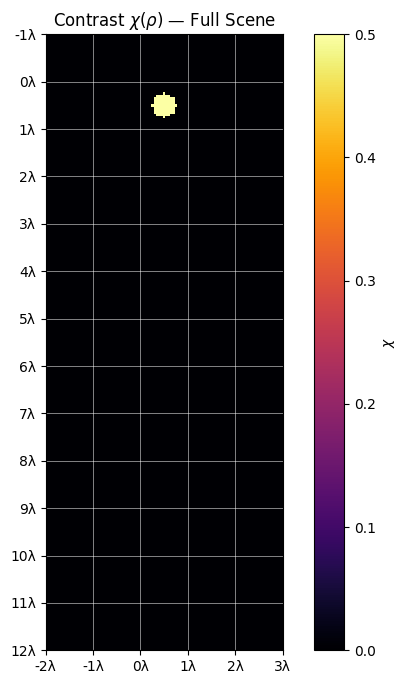

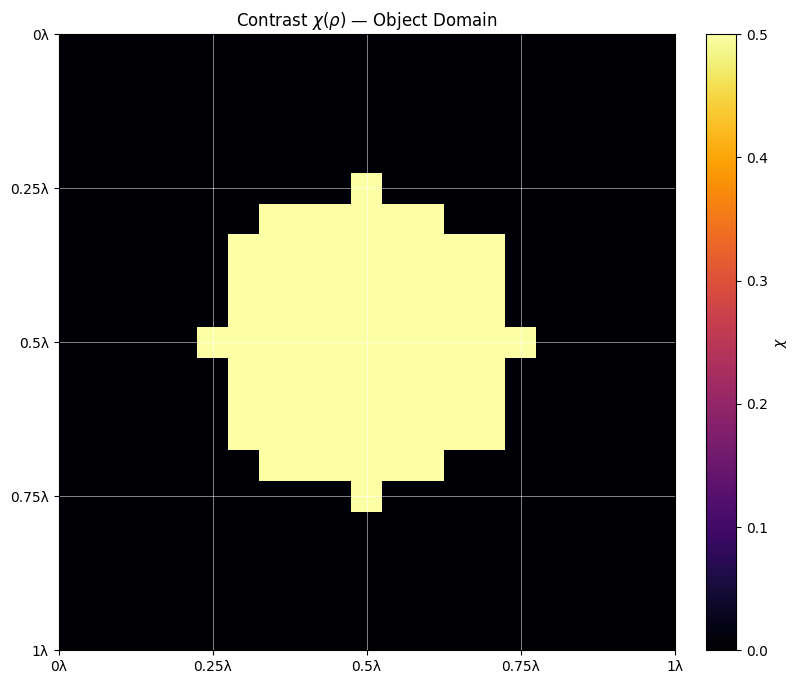

In [11]:
print("\nQuestions 8-9: Contrast function")
scene = setup_scene_basic()
# Use a circular contrast at center of domain
scene.add_contrast('Object', rho_0=[0.5 * mu, 0.5 * mu],
                   size=0.25 * mu, intensity=0.5, shape='circle')

scene.plot_scene()
scene.plot_contrast() # Contrast over the full grid
scene.plot_contrast(domain_name='Object Domain')

# Get contrast vector
chi_vec = scene.get_contrast_vector('Object Domain')

<span style="font-family:Ariel; font-size:24px; color:white">
10, 11) Receiver array
</span>

In [ ]:
# Add a linear array of 5 elements below the object domain
scene = setup_scene(M=5)
scene.plot_scene()

<span style="font-family:Ariel; font-size:24px; color:white">
13, 14) Build A matrix
</span>

  5000/26361 (19.0%)
  10000/26361 (37.9%)
  15000/26361 (56.9%)
  20000/26361 (75.9%)
  25000/26361 (94.8%)
  26361/26361 (100.0%)


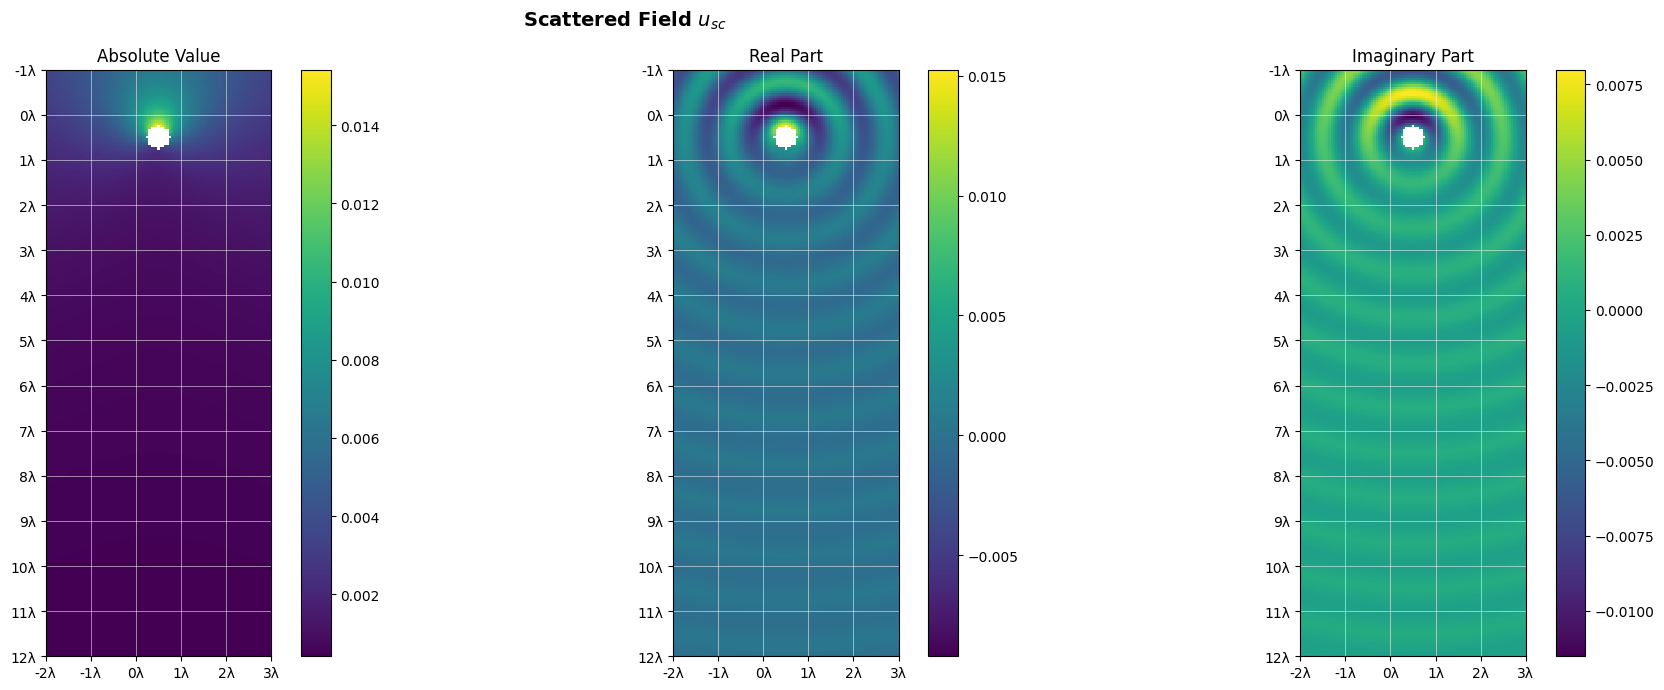

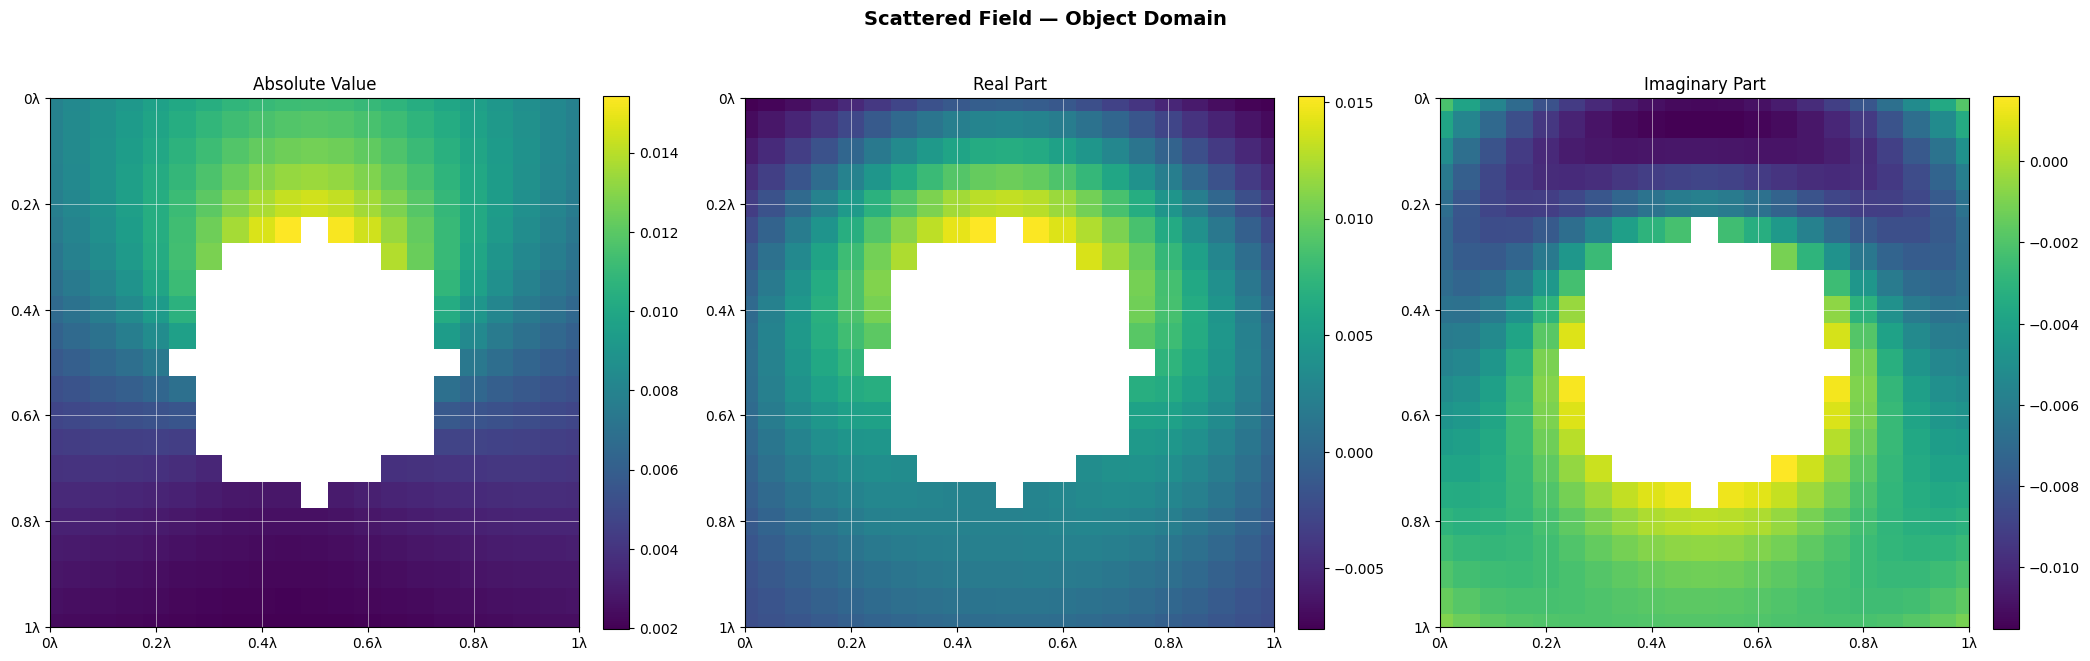

  A shape: (5, 441)
  N (domain pixels): 441
  M (receivers): 5


In [12]:
scene.compute(field_type='incident')
scene.compute_scattered_field()
scene.compute(field_type='total')
scene.plot_field(field_type='scattered')
scene.plot_domain_field('Object Domain', field_type='scattered')

A = scene.build_system_matrix('Object Domain', 'Receivers')
print(f"  A shape: {A.shape}")
print(f"  N (domain pixels): {A.shape[1]}")
print(f"  M (receivers): {A.shape[0]}")

<span style="font-family:Ariel; font-size:24px; color:white">
15) SVD analysis
</span>

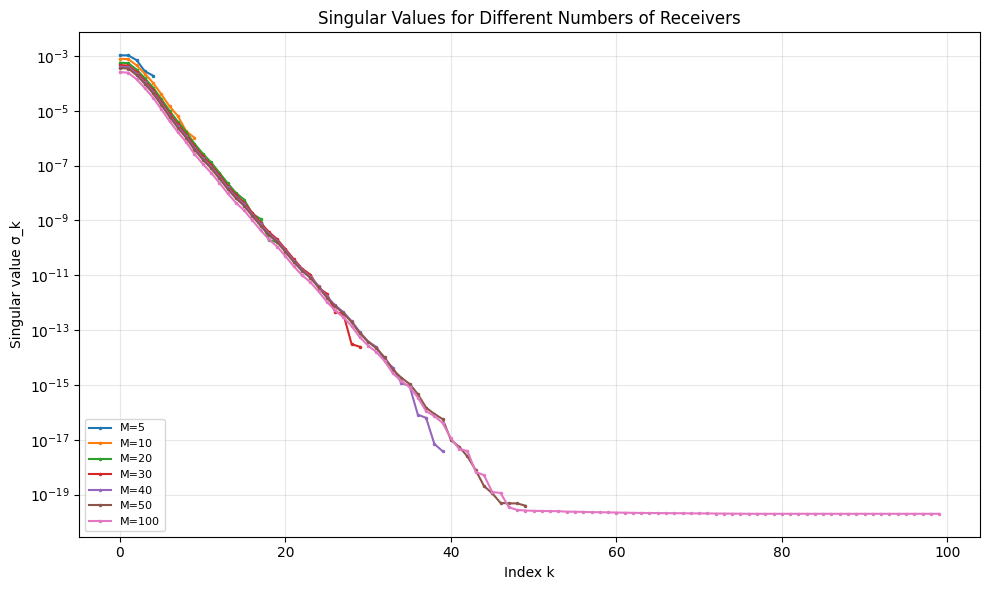

In [13]:
U_svd, S, Vh = np.linalg.svd(A, full_matrices=False)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

M_list = [5, 10, 20, 30, 40, 50, 100]

for M_test in M_list:
    scene_test = setup_scene(M=M_test)
    scene_test.add_contrast('Object', rho_0=[0.5 * mu, 0.5 * mu],
                            size=0.25 * mu, intensity=0.5, shape='circle')
    scene_test.compute(field_type='incident')
    scene_test.compute_scattered_field()
    A_test = scene_test.build_system_matrix('Object Domain', 'Receivers')
    _, S_test, _ = np.linalg.svd(A_test, full_matrices=False)
    
    ax.semilogy(S_test, '.-', markersize=3, label=f'M={M_test}')

ax.set_xlabel('Index k')
ax.set_ylabel('Singular value σ_k')
ax.set_title('Singular Values for Different Numbers of Receivers')
ax.legend(loc='lower left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()

<span style="font-family:Ariel; font-size:24px; color:white">
16) Compute scattered field
</span>

In [14]:
print("\nQuestion 16: Compute scattered field")

u_sc_direct = scene.U_sc['Receivers']
u_sc_matrix = A @ chi_vec

print(f"  |u_sc| range: [{np.abs(u_sc_direct).min():.2e}, {np.abs(u_sc_direct).max():.2e}]")
print(f"  A@chi vs direct max diff: {np.abs(u_sc_matrix - u_sc_direct).max():.2e}")


Question 16: Compute scattered field
  |u_sc| range: [1.41e-03, 1.83e-03]
  A@chi vs direct max diff: 1.46e-03


<span style="font-family:Ariel; font-size:24px; color:white">
17, 18) Object reconstruction (M=5)
</span>

  Using CLEAN data
  Pinv: 5/5 singular values kept
  Chi range: [-0.3467, 0.3714]
  Reconstruction error: 1.0808
  Chi range: [-0.3467, 0.3714]


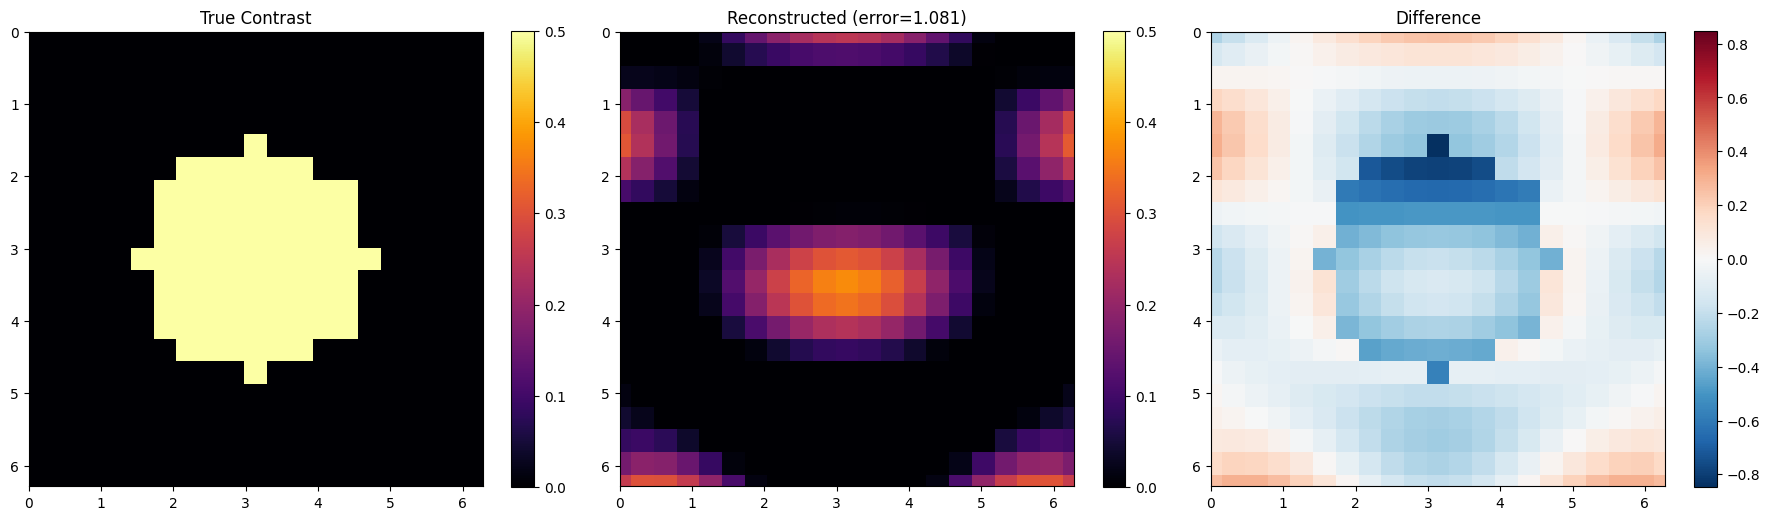

In [15]:
chi_recon = scene.solve_inverse('Object Domain', 'Receivers', method='pinv', plot_svd=False)
chi_true = scene.get_contrast_vector('Object Domain')
error = np.linalg.norm(chi_recon - chi_true) / np.linalg.norm(chi_true)

print(f"  Reconstruction error: {error:.4f}")
print(f"  Chi range: [{chi_recon.min():.4f}, {chi_recon.max():.4f}]")

scene.plot_reconstruction('Object Domain', chi_recon)

<span style="font-family:Ariel; font-size:24px; color:white">
19) Vary number of receivers M
</span>

  M = 5
  Using CLEAN data
  Pinv: 5/5 singular values kept
  Chi range: [-0.3467, 0.3714]


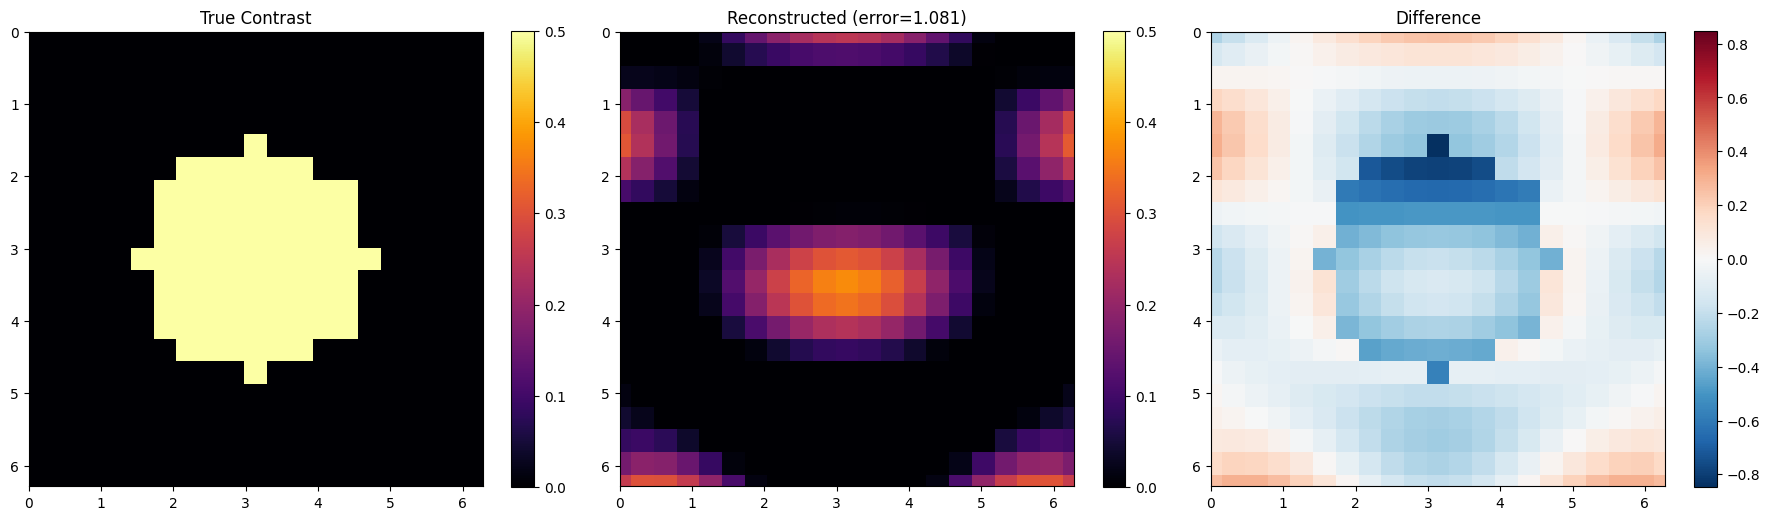

  M = 10
  Using CLEAN data
  Pinv: 10/10 singular values kept
  Chi range: [-1.4773, 1.1733]


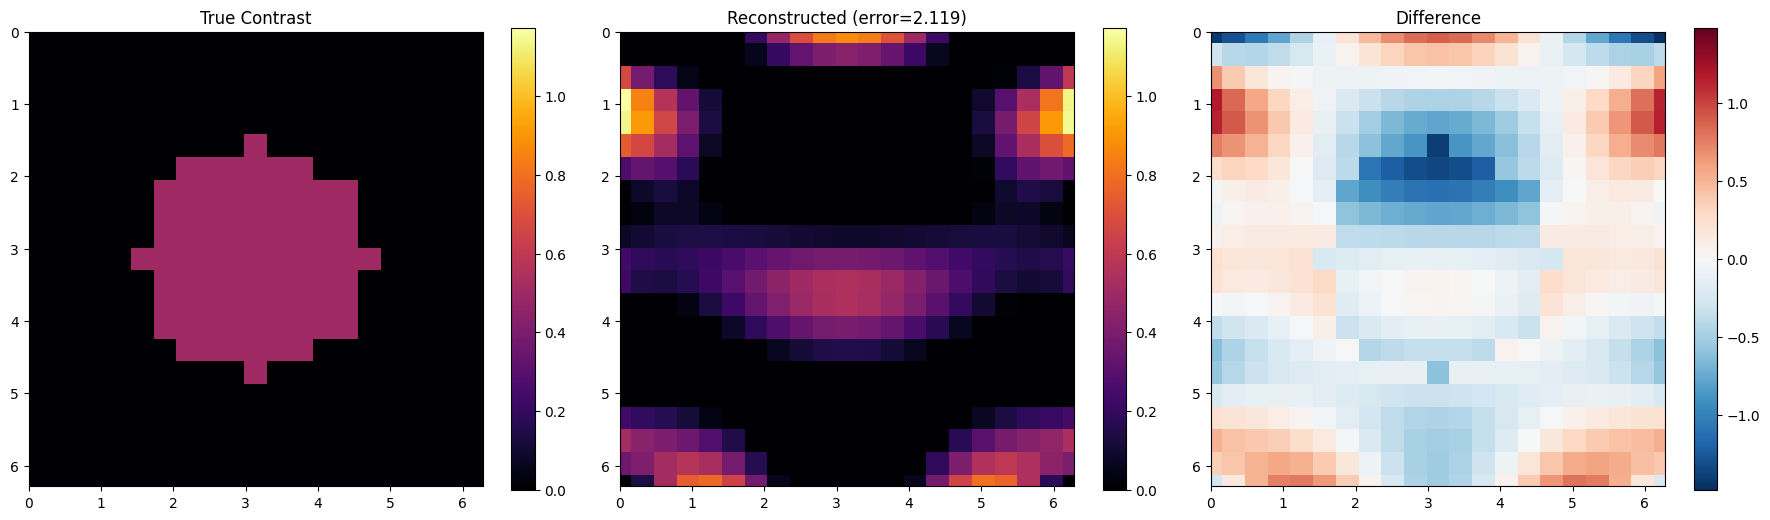

  M = 20
  Using CLEAN data
  Pinv: 20/20 singular values kept
  Chi range: [-6.8688, 5.6509]


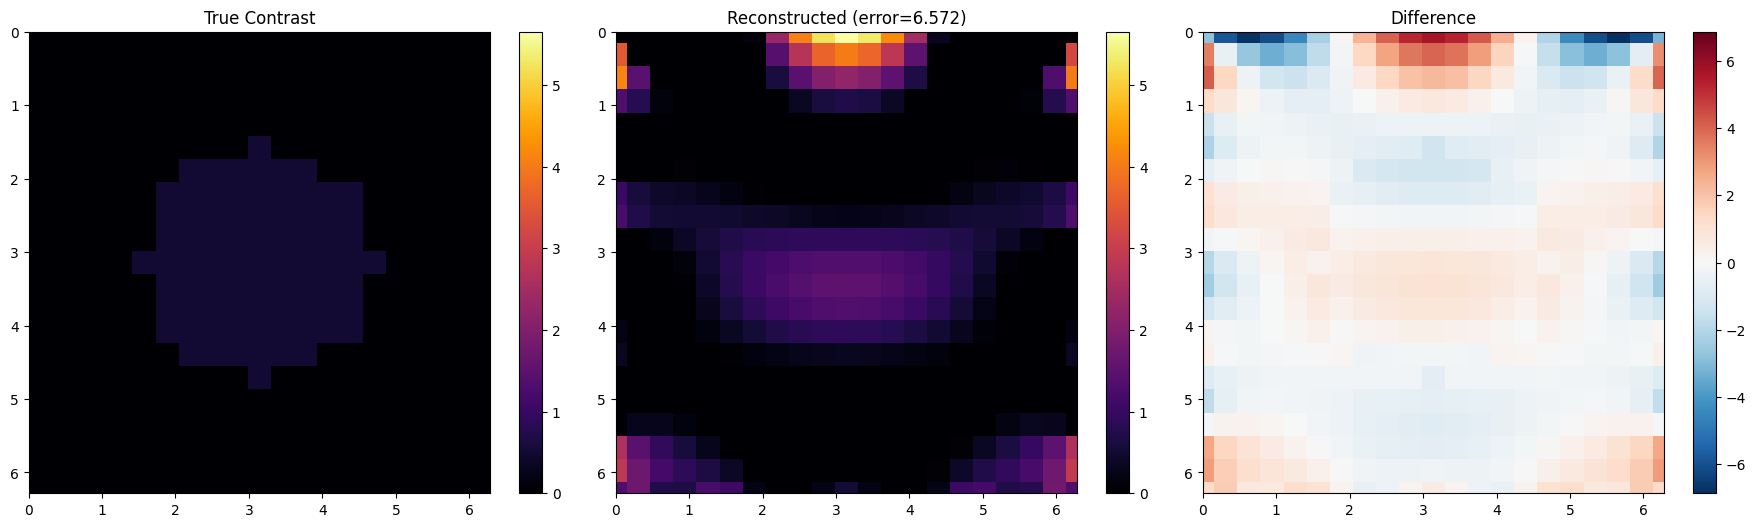

  M = 30
  Using CLEAN data
  Pinv: 28/30 singular values kept
  Chi range: [-13.0036, 12.3038]


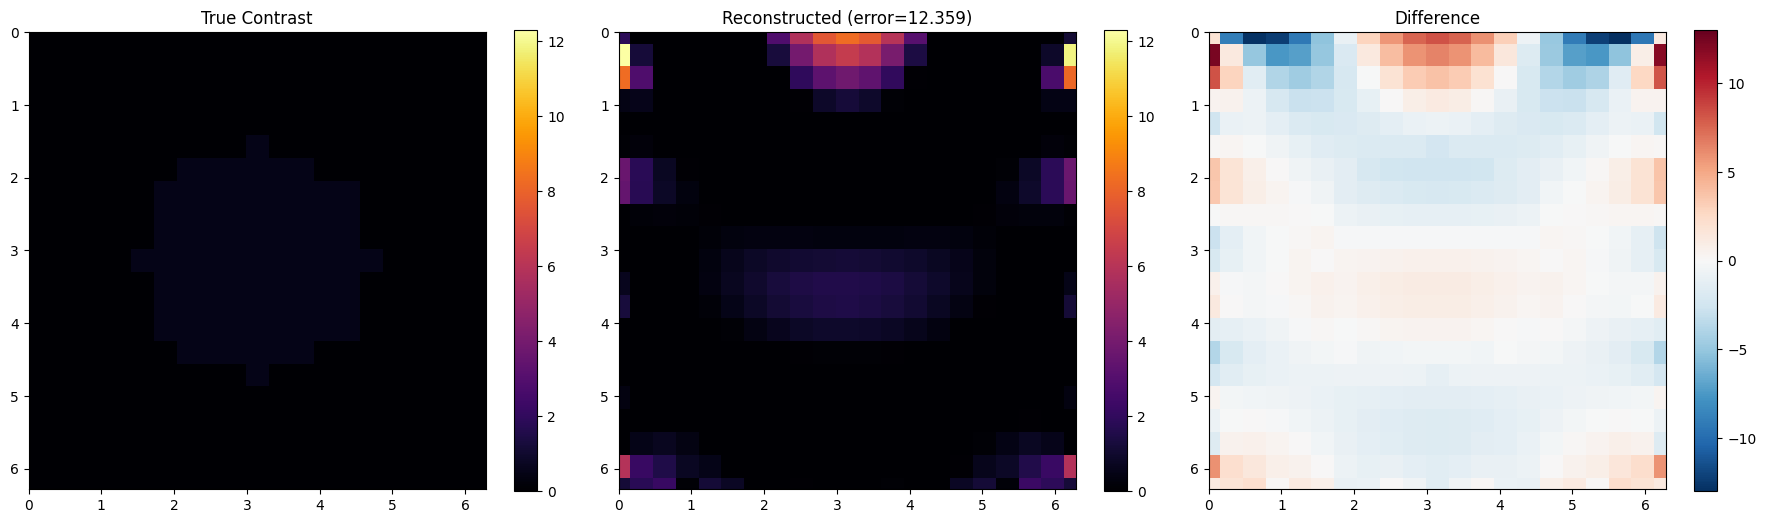

  M = 40
  Using CLEAN data
  Pinv: 30/40 singular values kept
  Chi range: [-17.4023, 16.8716]


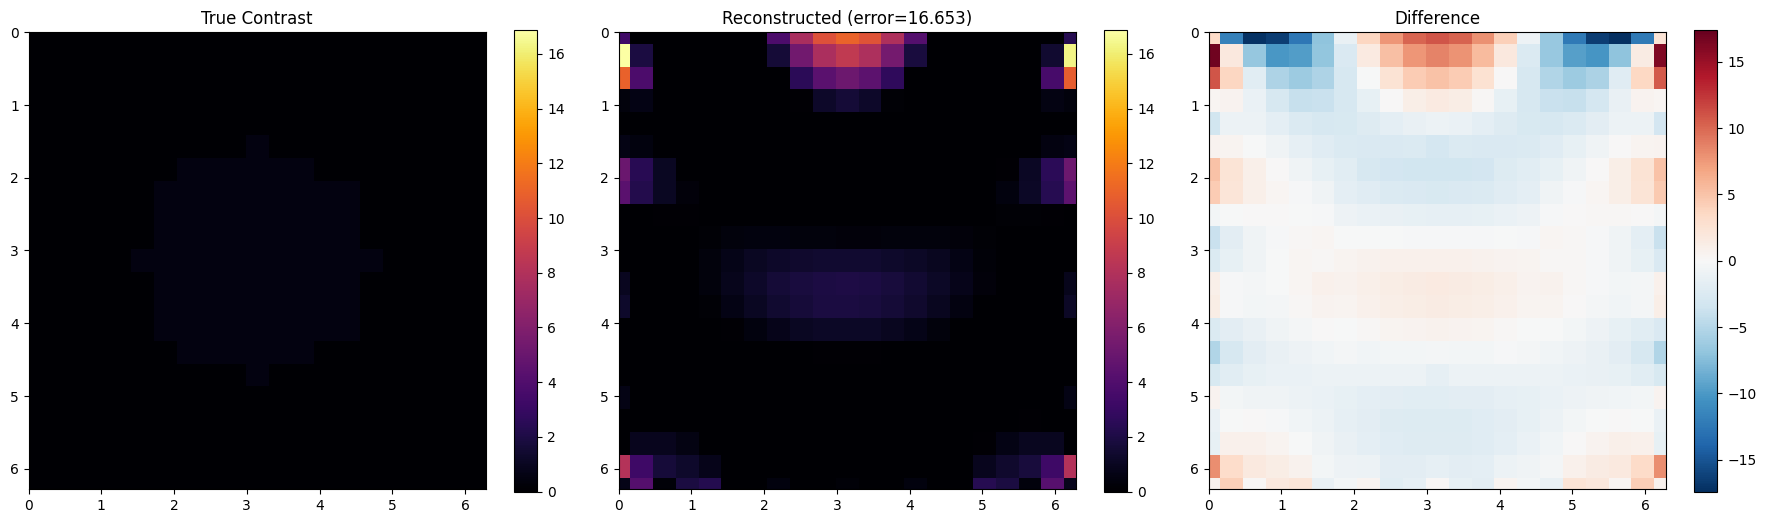

  M = 50
  Using CLEAN data
  Pinv: 31/50 singular values kept
  Chi range: [-21.8788, 23.3710]


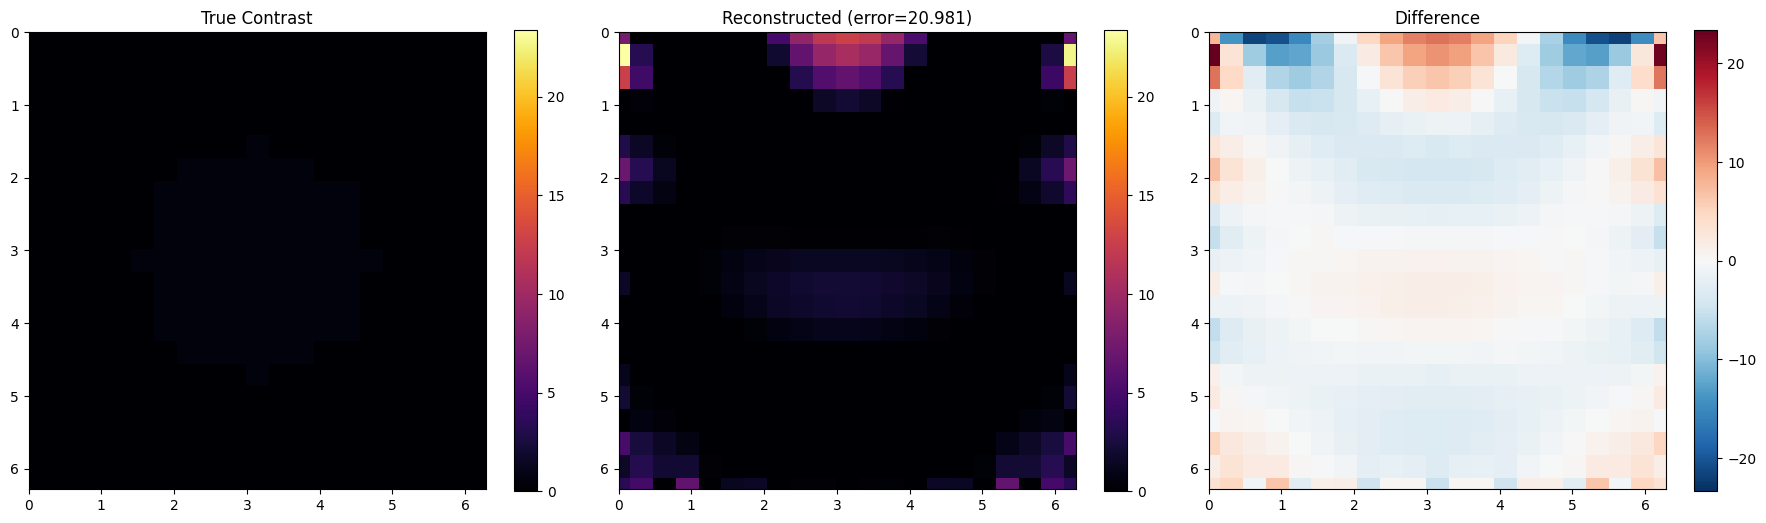

  M = 100
  Using CLEAN data
  Pinv: 31/100 singular values kept
  Chi range: [-43.8082, 46.8468]


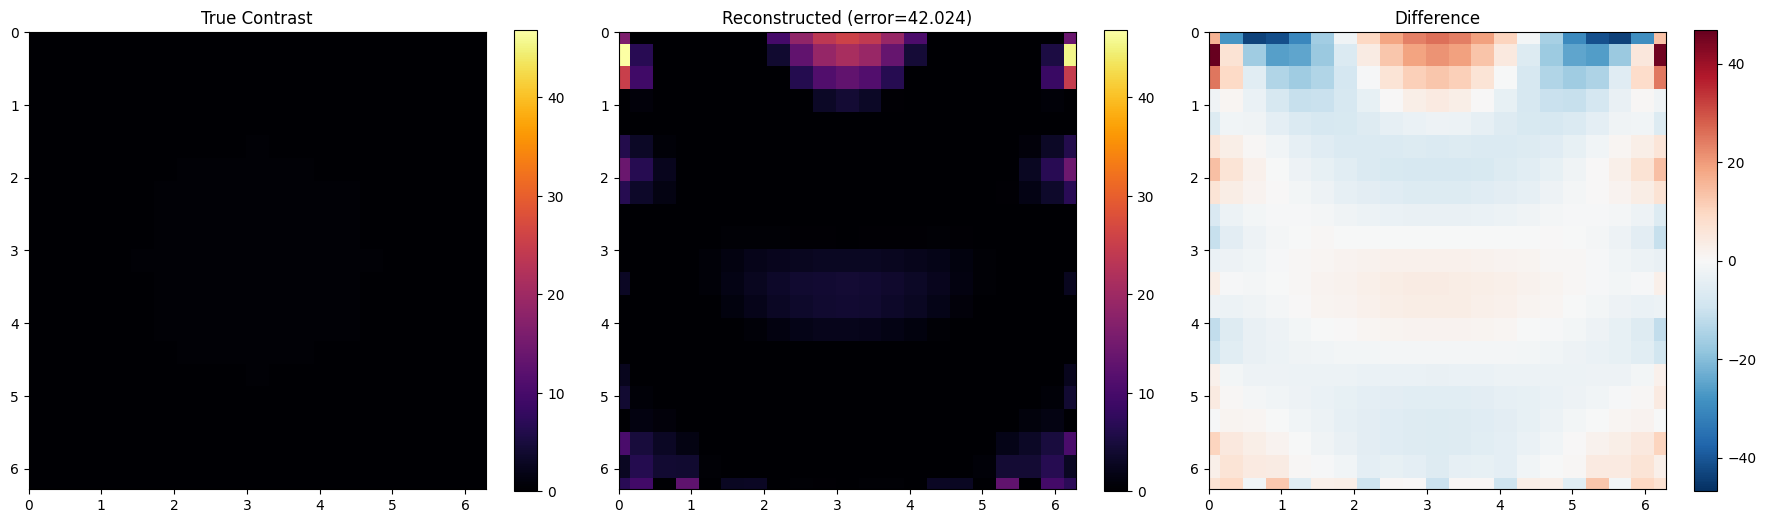

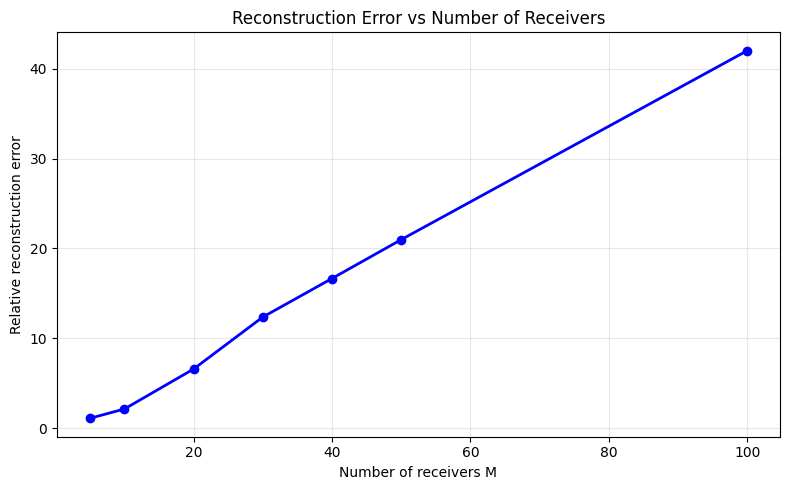

In [16]:
M_values = [5, 10, 20, 30, 40, 50, 100]
errors = []

for M_test in M_values:
    print(f"  M = {M_test}")
    scene_test = setup_scene(M=M_test)
    scene_test.add_contrast('Object', rho_0=[0.5 * mu, 0.5 * mu],
                            size=0.25 * mu, intensity=0.5, shape='circle')
    scene_test.compute(field_type='incident')
    scene_test.compute_scattered_field()

    chi_recon_test = scene_test.solve_inverse('Object Domain', 'Receivers',
                                              method='pinv', plot_svd=False)
    chi_true_test = scene_test.get_contrast_vector('Object Domain')
    error_test = np.linalg.norm(chi_recon_test - chi_true_test) / np.linalg.norm(chi_true_test)
    errors.append(error_test)

    A_test = scene_test.build_system_matrix('Object Domain', 'Receivers')
    _, S_test, _ = np.linalg.svd(A_test, full_matrices=False)

    scene_test.plot_reconstruction('Object Domain', chi_recon_test)

# Plot error vs M
fig, ax1 = plt.subplots(1, 1, figsize=(8, 5))
ax1.plot(M_values, errors, 'bo-', linewidth=2)
ax1.set_xlabel('Number of receivers M')
ax1.set_ylabel('Relative reconstruction error')
ax1.set_title('Reconstruction Error vs Number of Receivers')
ax1.grid(True, alpha=0.3)
plt.tight_layout()

<span style="font-family:Ariel; font-size:24px; color:white">
20) Noise investigation
</span>


Question 20: Noise investigation
  SNR = 10 dB
  SNR = 10 dB, P_signal = 2.71e-06, P_noise = 2.71e-07
  Using NOISY data (SNR=10 dB)
  Pinv: 20/20 singular values kept
  Chi range: [-10.0000, 10.0000]


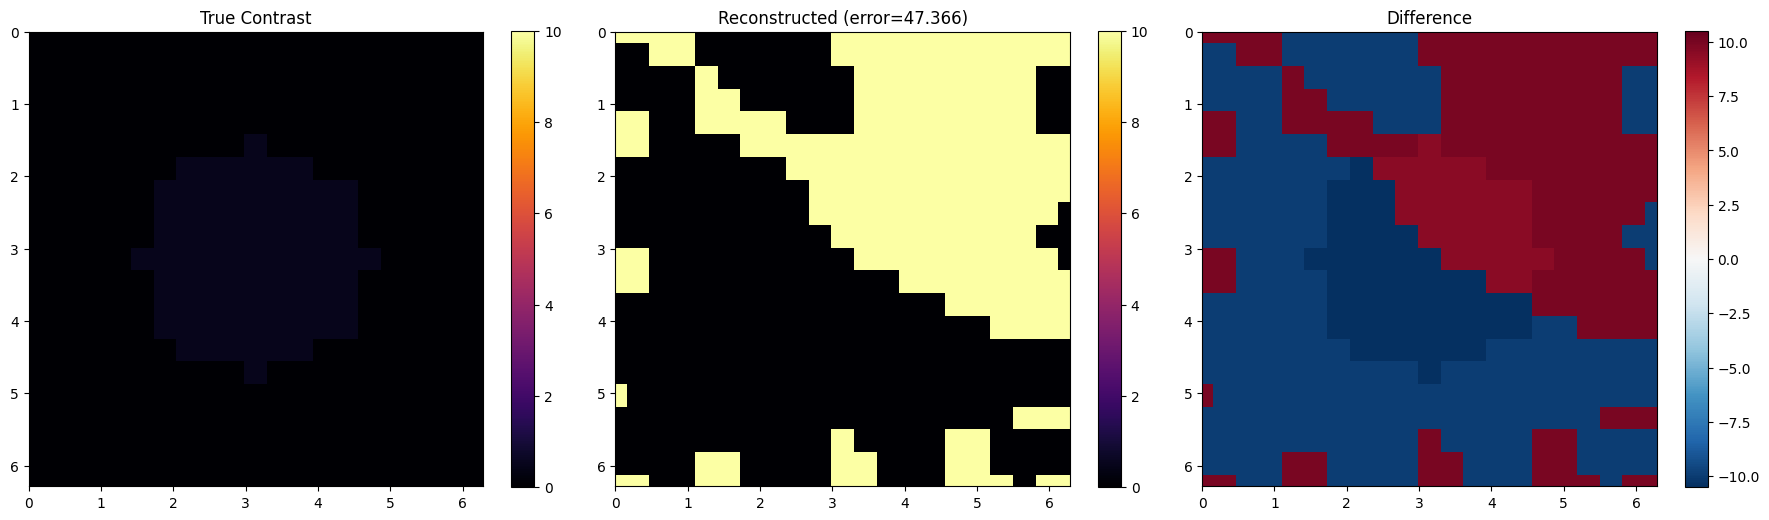

  SNR = 20 dB
  SNR = 20 dB, P_signal = 2.71e-06, P_noise = 2.71e-08
  Using NOISY data (SNR=20 dB)
  Pinv: 20/20 singular values kept
  Chi range: [-10.0000, 10.0000]


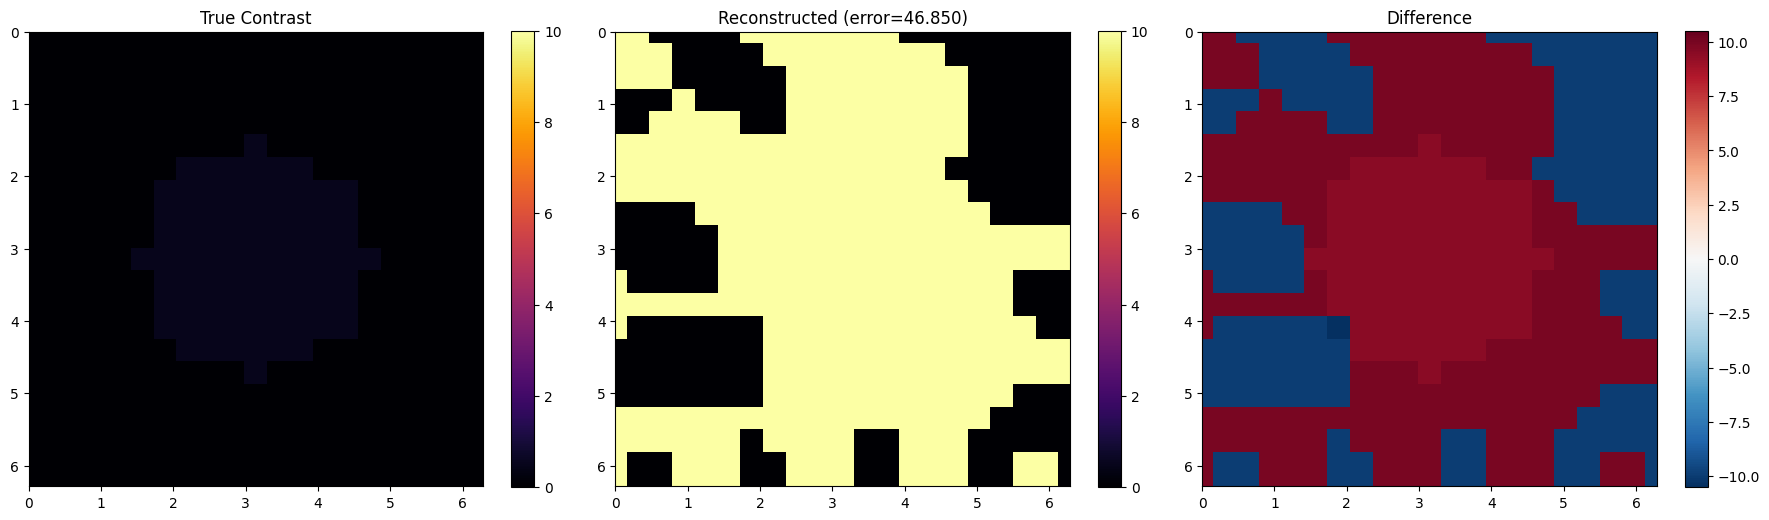

  SNR = 30 dB
  SNR = 30 dB, P_signal = 2.71e-06, P_noise = 2.71e-09
  Using NOISY data (SNR=30 dB)
  Pinv: 20/20 singular values kept
  Chi range: [-10.0000, 10.0000]


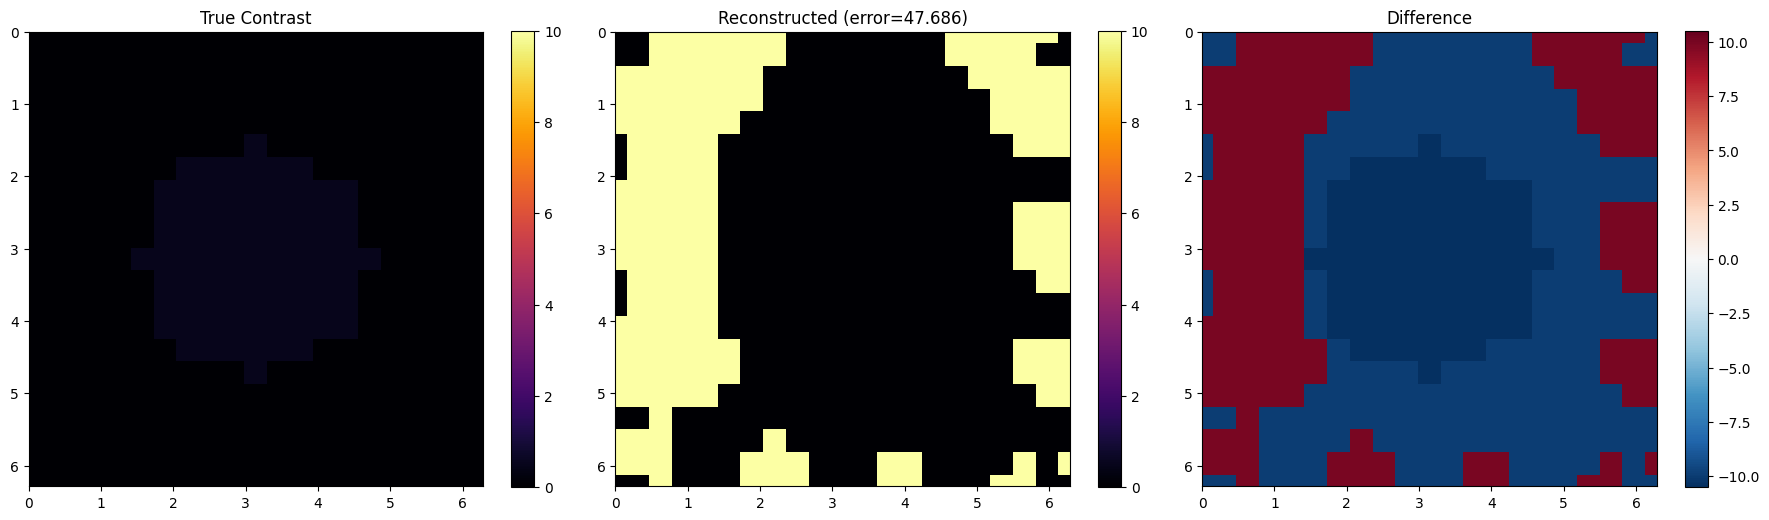

  SNR = 40 dB
  SNR = 40 dB, P_signal = 2.71e-06, P_noise = 2.71e-10
  Using NOISY data (SNR=40 dB)
  Pinv: 20/20 singular values kept
  Chi range: [-10.0000, 10.0000]


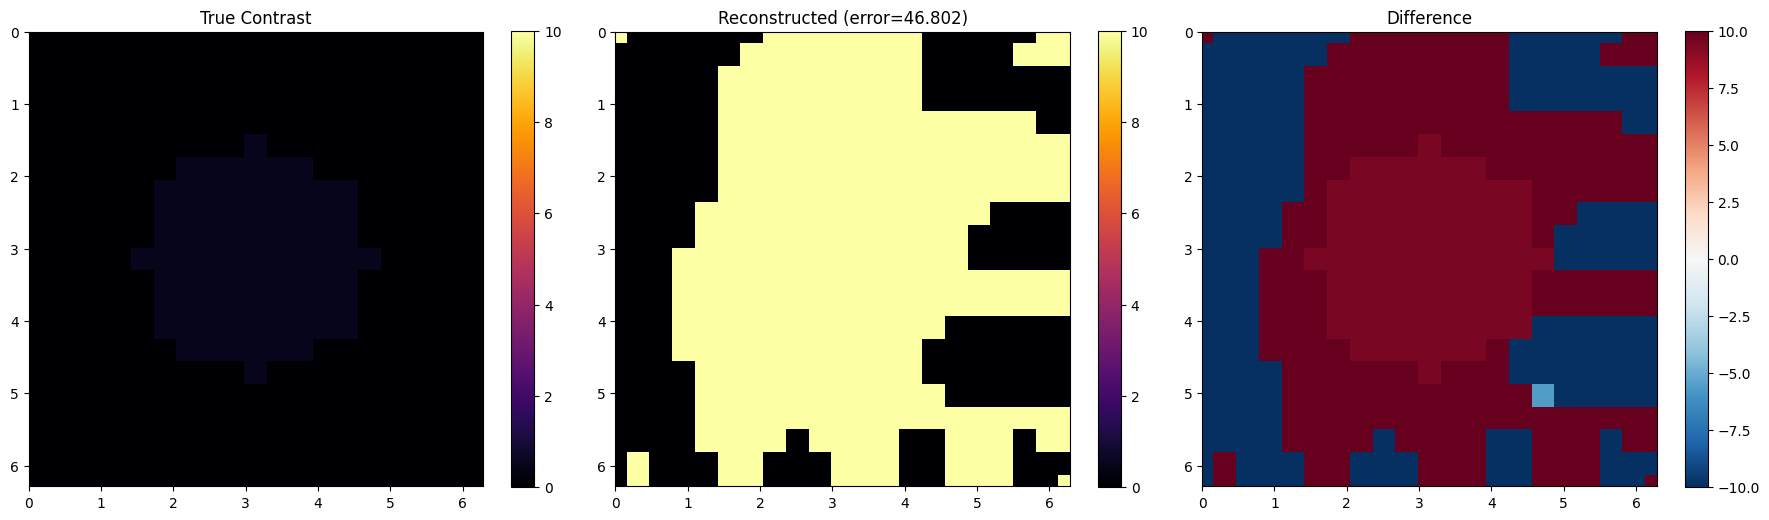

  SNR = 60 dB
  SNR = 60 dB, P_signal = 2.71e-06, P_noise = 2.71e-12
  Using NOISY data (SNR=60 dB)
  Pinv: 20/20 singular values kept
  Chi range: [-10.0000, 10.0000]


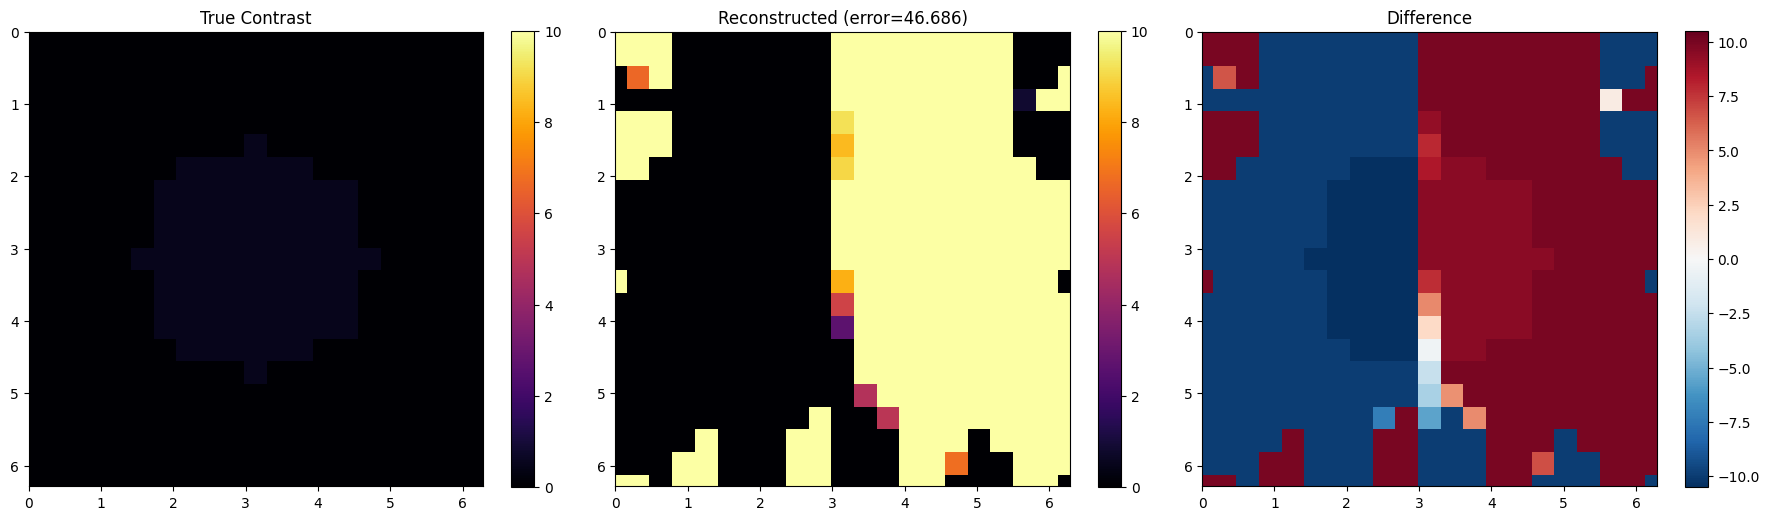

  Using CLEAN data
  Pinv: 20/20 singular values kept
  Chi range: [-6.8688, 5.6509]


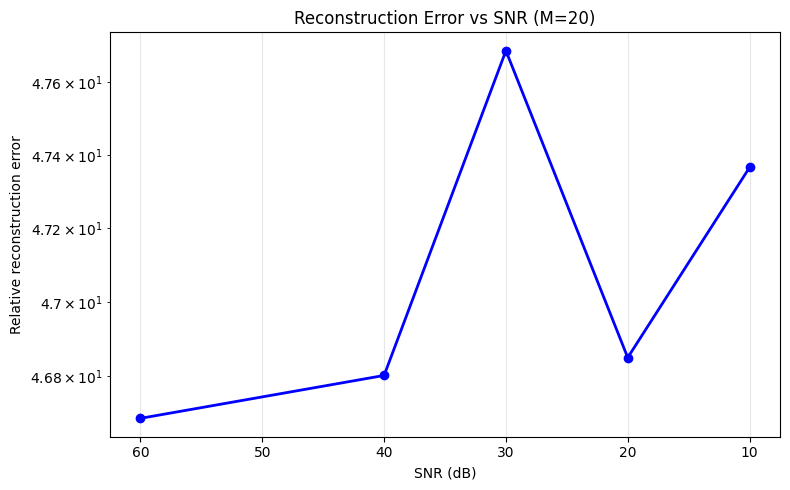

In [17]:
print("\nQuestion 20: Noise investigation")
SNR_values = [10, 20, 30, 40, 60]
noise_errors = []

for snr in SNR_values:
    print(f"  SNR = {snr} dB")
    scene_test = setup_scene(M=20)
    scene_test.add_contrast('Object', rho_0=[0.5 * mu, 0.5 * mu],
                            size=0.25 * mu, intensity=0.5, shape='circle')
    scene_test.compute(field_type='incident')
    scene_test.compute_scattered_field()
    scene_test.add_noise('Receivers', SNR_dB=snr, noise_type='gaussian')

    chi_noisy = scene_test.solve_inverse('Object Domain', 'Receivers',
                                         method='pinv', use_noisy=True, plot_svd=False)
    chi_true_test = scene_test.get_contrast_vector('Object Domain')
    error_noisy = np.linalg.norm(chi_noisy - chi_true_test) / np.linalg.norm(chi_true_test)
    noise_errors.append(error_noisy)

    scene_test.plot_reconstruction('Object Domain', chi_noisy)

# Plot error vs SNR
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.semilogy(SNR_values, noise_errors, 'bo-', linewidth=2)
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Relative reconstruction error')
ax.set_title('Reconstruction Error vs SNR (M=20)')
ax.grid(True, alpha=0.3)
ax.invert_xaxis()
plt.tight_layout()

# Also compare clean vs noisy
scene_clean = setup_scene(M=20)
scene_clean.add_contrast('Object', rho_0=[0.5 * mu, 0.5 * mu],
                         size=0.25 * mu, intensity=0.5, shape='circle')
scene_clean.compute(field_type='incident')
scene_clean.compute_scattered_field()
chi_clean = scene_clean.solve_inverse('Object Domain', 'Receivers', method='pinv', plot_svd=False)
